# ETL Pipeline for Credit Risk Data

This notebook performs Extract, Transform, Load (ETL) operations to prepare the credit risk dataset for modeling.

**Steps:**
- Load raw data
- Clean and preprocess
- Encode categorical variables
- Handle missing values
- Save model-ready CSV
- (Optional) EDA summary

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Raw Data

In [2]:
raw_path = '../data/credir_risk_reto_modified.csv'
df = pd.read_csv(raw_path)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,description,target
0,67,male,2,own,NaN,little,1169,6,radio/TV,"The 67 year old male has a skilled job, owns h...",bad risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,The person is a 22 year old female with a skil...,bad risk
2,49,male,1,own,little,NaN,2096,12,education,A 49 year old male with an unskilled and resid...,good risk
3,45,male,2,free,little,little,7882,42,furniture/equipment,The person is a 45 year old male with a skille...,bad risk
4,53,male,2,free,little,little,4870,24,car,The 53 year old male has a skilled job and liv...,bad risk


## 2. Initial Data Inspection & Nulls

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   description       1000 non-null   object
 10  target            1000 non-null   object
dtypes: int64(4), object(7)
memory usage: 86.1+ KB


Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
description           0
target                0
dtype: int64

## 3. Handle Missing Values
- For 'Saving accounts' and 'Checking account', fill NaN with 'unknown' (or another strategy).
- For other fields, drop or impute as appropriate.

In [4]:
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
# Drop rows with null target (if any)
df = df[df['target'].notnull()]
df.reset_index(drop=True, inplace=True)
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
description         0
target              0
dtype: int64

## 4. Encode Categorical Variables
- Use LabelEncoder for simplicity.
- Save encoders if needed for inference.

In [5]:
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
# Encode target
df['target'] = df['target'].map({'good risk': 1, 'bad risk': 0})

## 5. Drop Unused Columns
- Drop 'description' if present.

In [6]:
if 'description' in df.columns:
    df = df.drop(columns=['description'])
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,67,1,2,1,4,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,0
4,53,1,2,0,0,0,4870,24,1,0


## 6. Save Model-Ready Data

In [9]:
output_path = '../data/credir_risk_reto_modified_prepared.csv'
df.to_csv(output_path, index=False)
print(f'Saved cleaned data to {output_path}')

Saved cleaned data to ../data/credir_risk_reto_modified_prepared.csv


## (Optional) 7. EDA Summary
- Visualize distributions, correlations, etc.

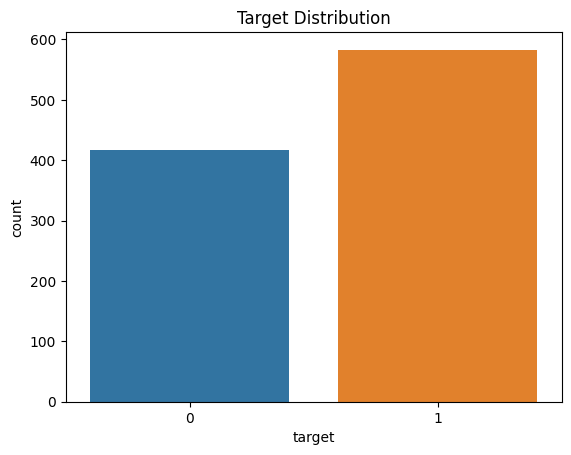

In [8]:
# Example: Distribution of target
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()